In [1]:
import os
import configparser
import subprocess

from getdist import plots, loadMCSamples
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.stats as stats
from IPython.display import Markdown, display
import healpy as hp
%matplotlib inline
# import uncertainties

plt.rc('mathtext', fontset='stix')
plt.rc('font', family='sans-serif')

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40


#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir='/n09data/guerrini/output_chains/'

catalog_version = 'SP_v1.4.5_A'

path_ini_files = '/home/guerrini/sp_validation/cosmo_inference/cosmosis_config/'

roots = [
    "SP_v1.4.5_A",
    "SP_v1.4.5_A_no_IA",
    "SP_v1.4.5_A_no_dz",
    "SP_v1.4.5_A_no_m_bias",
    "SP_v1.4.5_A_sc_3_150",
    "SP_v1.4.5_A_sc_3_60",
    "SP_v1.4.5_A_sc_10_150",
    "SP_v1.4.5_A_sc_10_60",
    "SP_v1.4.5_A_sc_5_150",
    "SP_v1.4.5_A_sc_7_150",
    "SP_v1.4.5_A_no_leakage"
]

properties = {}

for root in roots:
    config = configparser.ConfigParser()
    config.optionxform = str  # Preserve case sensitivity of option names
    config.read(path_ini_files+f'/cosmosis_pipeline_{root}.ini')

    add_xi_sys = config["2pt_like"]["add_xi_sys"]
    add_xi_sys = add_xi_sys == 'T'
    lower_bound_xi_plus, upper_bound_xi_plus = map(float, config["2pt_like"]["angle_range_XI_PLUS_1_1"].split())
    lower_bound_xi_minus, upper_bound_xi_minus = map(float, config["2pt_like"]["angle_range_XI_MINUS_1_1"].split())

    properties[root] = {
        'add_xi_sys': add_xi_sys,
        'lower_bound_xi_plus': lower_bound_xi_plus,
        'upper_bound_xi_plus': upper_bound_xi_plus,
        'lower_bound_xi_minus': lower_bound_xi_minus,
        'upper_bound_xi_minus': upper_bound_xi_minus
    }


print(roots)

['SP_v1.4.5_A', 'SP_v1.4.5_A_no_IA', 'SP_v1.4.5_A_no_dz', 'SP_v1.4.5_A_no_m_bias', 'SP_v1.4.5_A_sc_3_150', 'SP_v1.4.5_A_sc_3_60', 'SP_v1.4.5_A_sc_10_150', 'SP_v1.4.5_A_sc_10_60', 'SP_v1.4.5_A_sc_5_150', 'SP_v1.4.5_A_sc_7_150', 'SP_v1.4.5_A_no_leakage']


## Retrieve the chains

In [2]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [3]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.3,
                                         'smooth_scale_1D':0.3})

    chains.append(chain)

2502
/n09data/guerrini/output_chains/SP_v1.4.5_A/getdist_SP_v1.4.5_A.txt
Removed no burn in
2513
/n09data/guerrini/output_chains/SP_v1.4.5_A_no_IA/getdist_SP_v1.4.5_A_no_IA.txt
Removed no burn in
2578
/n09data/guerrini/output_chains/SP_v1.4.5_A_no_dz/getdist_SP_v1.4.5_A_no_dz.txt
Removed no burn in
2484
/n09data/guerrini/output_chains/SP_v1.4.5_A_no_m_bias/getdist_SP_v1.4.5_A_no_m_bias.txt
Removed no burn in
2526
/n09data/guerrini/output_chains/SP_v1.4.5_A_sc_3_150/getdist_SP_v1.4.5_A_sc_3_150.txt
Removed no burn in
2527
/n09data/guerrini/output_chains/SP_v1.4.5_A_sc_3_60/getdist_SP_v1.4.5_A_sc_3_60.txt
Removed no burn in
2058
/n09data/guerrini/output_chains/SP_v1.4.5_A_sc_10_150/getdist_SP_v1.4.5_A_sc_10_150.txt
Removed no burn in
2035
/n09data/guerrini/output_chains/SP_v1.4.5_A_sc_10_60/getdist_SP_v1.4.5_A_sc_10_60.txt
Removed no burn in
2388
/n09data/guerrini/output_chains/SP_v1.4.5_A_sc_5_150/getdist_SP_v1.4.5_A_sc_5_150.txt
Removed no burn in
2218
/n09data/guerrini/output_chains/S

In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1','alpha','beta']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1', '\\alpha_{PSF}', '\\beta_{PSF}']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label
    

## Extract the best fit parameters

In [11]:
best_fit = {}

for root, chain in zip(roots, chains):
    print(root)
    likestats = chain.getLikeStats()
    bestfit_idx = np.argmax(chain.loglikes)
    maxlike = chain.loglikes[bestfit_idx]
    print(f"Maximum Likelihood: {maxlike:.5g}")
    best_fit[root] = {
        'likelihood': maxlike
    }
    for i, par in enumerate(likestats.names):
        best_fit[root].update({par.name: np.average(chain.samples[:, i], weights=chain.weights)})
    

SP_v1.4.5_A
Maximum Likelihood: -53.079
SP_v1.4.5_A_no_IA
Maximum Likelihood: -54.152
SP_v1.4.5_A_no_dz
Maximum Likelihood: -54.376
SP_v1.4.5_A_no_m_bias
Maximum Likelihood: -53.158
SP_v1.4.5_A_sc_3_150
Maximum Likelihood: -52.815
SP_v1.4.5_A_sc_3_60
Maximum Likelihood: -49.423
SP_v1.4.5_A_sc_10_150
Maximum Likelihood: -48.761
SP_v1.4.5_A_sc_10_60
Maximum Likelihood: -45.907
SP_v1.4.5_A_sc_5_150
Maximum Likelihood: -53.159
SP_v1.4.5_A_sc_7_150
Maximum Likelihood: -52.607
SP_v1.4.5_A_no_leakage
Maximum Likelihood: -53.416


## Run `Cosmosis` in test mode to get the data vectors

In [6]:
if not os.path.exists(path_ini_files+'/values_empty.ini'):
    content = """[cosmological_parameters]

tau          =  0.0544
w            = -1.0
massive_nu   =  1
massless_nu  =  2.046
omega_k      =  0.0
wa           =  0.0

[halo_model_parameters]

[intrinsic_alignment_parameters]

[shear_calibration_parameters]

[nofz_shifts]

[psf_leakage_parameters]
"""

    with open(path_ini_files+'/values_empty.ini', 'w') as f:
        f.write(content)
        f.close()

    print('File created successfully')

In [7]:
section_map = {
    'omch2': 'cosmological_parameters',
    'ombh2': 'cosmological_parameters',
    'h0': 'cosmological_parameters',
    'n_s': 'cosmological_parameters',
    's_8_input': 'cosmological_parameters',
    'logt_agn': 'halo_model_parameters',
    'a': 'intrinsic_alignment_parameters',
    'm1': 'shear_calibration_parameters',
    'bias_1': 'nofz_shifts',
    'alpha': 'psf_leakage_parameters',
    'beta': 'psf_leakage_parameters',
}

In [8]:
env = os.environ.copy()
env["LD_LIBRARY_PATH"] = "/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/cosmosis/datablock:" + env.get("LD_LIBRARY_PATH", "")

for root in roots:
    print(root)
    config = configparser.ConfigParser()
    config.optionxform = str  # Preserve case sensitivity of option names
    config.read(path_ini_files+'/values_empty.ini')
    for param, value in best_fit[root].items():
        section = section_map.get(param)
        if section is None:
            continue
        if section not in config:
            config.add_section(section)
        config[section][param] = str(value)

    with open(path_ini_files+'/values_empty.ini', 'w') as configfile:
        config.write(configfile)

    #Modify the ini file to run in test mode at the best fit
    config = configparser.ConfigParser()
    config.optionxform = str  # Preserve case sensitivity of option names
    config.read(path_ini_files+f'/cosmosis_pipeline_{root}.ini')

    sampler = config['runtime']['sampler']
    config['runtime']['sampler'] = 'test'
    values = config['pipeline']['values']
    config['pipeline']['values'] = path_ini_files + '/values_empty.ini'

    with open(path_ini_files+f'/cosmosis_pipeline_{root}.ini', 'w') as configfile:
        config.write(configfile)

    #Run cosmosis
    result = subprocess.run(
        ['cosmosis',  'cosmosis_config/cosmosis_pipeline_{}.ini'.format(root)],
        env=env,
        capture_output=True,
        text=True
    )
    print(f"STDOUT:\n{result.stdout}")
    print(f"STDERR:\n{result.stderr}")

    #Modify the ini file to the previous one
    config['pipeline']['values'] = values
    config['runtime']['sampler'] = sampler

    with open(path_ini_files+f'/cosmosis_pipeline_{root}.ini', 'w') as configfile:
        config.write(configfile)

SP_v1.4.5_A
STDOUT:
Setting up pipeline from parameter file cosmosis_config/cosmosis_pipeline_SP_v1.4.5_A.ini
-----------------------------------------------------------------------------------------

Setting up module consistency
------------------------------

Setting up module sample_S8
----------------------------

Setting up module camb
-----------------------
**** WARNING: Parameter 'kmin' in the [camb] section never used!


Setting up module load_nz_fits
-------------------------------
Loading number density data from data/SP_v1.4.5_A/cosmosis_SP_v1.4.5.fits:
    Looking at FITS extension NZ_SOURCE:
        Found 1 bins
        Putting n(0) = 0 at the start of the n(z)

Setting up module photoz_bias
------------------------------

Setting up module linear_alignment
-----------------------------------

Setting up module projection
-----------------------------
Calculating Limber: Kernel 1 = ('W', 'source'), Kernel 2 = ('W', 'source'), P_3D = MatterPower3D, section = matter_power_

## Compute the $\chi^2$

In [103]:
output_folder = '/n09data/guerrini/output_chains/'

metrics = {}

for root in roots:
    print(root)

    add_xi_sys = properties[root]['add_xi_sys']
    lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
    upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
    lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
    upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

    #Read the results
    theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
    theta_arcmin = theta * 180 * 60 / np.pi
    shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
    shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
    xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
    xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))

    #Read model tau_stats
    theta_tau = np.loadtxt(output_folder + 'best_fit/{}/tau_0_plus/theta.txt'.format(root))
    theta_tau_arcmin = theta_tau * 180 * 60 / np.pi
    tau_0_model = np.loadtxt(output_folder + 'best_fit/{}/tau_0_plus/bin_1_1.txt'.format(root))
    tau_2_model = np.loadtxt(output_folder + 'best_fit/{}/tau_2_plus/bin_1_1.txt'.format(root))

    #Read the data
    data = fits.open(f'data/{catalog_version}/cosmosis_SP_v1.4.5.fits')

    theta_data = data['XI_PLUS'].data['ANG']
    xi_plus_data = data['XI_PLUS'].data['VALUE']
    xi_minus_data = data['XI_MINUS'].data['VALUE']
    tau_0_data = data['TAU_0_PLUS'].data['VALUE']
    tau_2_data = data['TAU_2_PLUS'].data['VALUE']

    #Load the covariance
    cov = data['COVMAT'].data
    cov_xi = cov[0:2*len(xi_plus_data), 0:2*len(xi_plus_data)]
    cov_tau = cov[2*len(xi_plus_data):, 2*len(xi_plus_data):]

    #interpolate the model
    interp_xi_plus = interp1d(theta_arcmin, shear_xi_plus, kind='cubic', fill_value='extrapolate')
    interp_xi_minus = interp1d(theta_arcmin, shear_xi_minus, kind='cubic', fill_value='extrapolate')

    xi_plus_model = interp_xi_plus(theta_data)
    if add_xi_sys:
        xi_plus_model += xi_sys_plus
    xi_minus_model = interp_xi_minus(theta_data)
    if add_xi_sys:
        xi_minus_model += xi_sys_minus

    #Concatenate the data vector
    xi_data = np.concatenate((xi_plus_data, xi_minus_data))
    xi_model = np.concatenate((xi_plus_model, xi_minus_model))

    tau_data = np.concatenate((tau_0_data, tau_2_data))
    tau_model = np.concatenate((tau_0_model, tau_2_model))

    #Apply scale cuts
    mask_xi_plus = (theta_data > lower_bound_xi_plus) & (theta_data < upper_bound_xi_plus)
    mask_xi_minus = (theta_data > lower_bound_xi_minus) & (theta_data < upper_bound_xi_minus)
    mask = np.concatenate((mask_xi_plus, mask_xi_minus))

    xi_data = xi_data[mask]
    xi_model = xi_model[mask]
    cov_xi = cov_xi[mask][:, mask]


    xi_plus_chi2 = np.dot((xi_model - xi_data), np.dot(np.linalg.inv(cov_xi), (xi_model - xi_data)))
    tau_chi2 = np.dot((tau_model - tau_data), np.dot(np.linalg.inv(cov_tau), (tau_model - tau_data)))
    n_dof_xi = np.sum(mask)
    n_dof_tau = len(tau_0_data) + len(tau_2_data)
    p_value_xi = 1 - stats.chi2.cdf(xi_plus_chi2, n_dof)
    p_value_tau = 1 - stats.chi2.cdf(tau_chi2, n_dof_tau)
    chi2_tot = xi_plus_chi2 + tau_chi2
    n_dof_tot = n_dof_xi + n_dof_tau
    p_value_tot = 1 - stats.chi2.cdf(chi2_tot, n_dof_tot)

    metrics[root] = {
        'chi2_xi': xi_plus_chi2,
        'n_dof_xi': n_dof_xi,
        'p_value_xi': p_value_xi,
        'chi2_tau': tau_chi2,
        'n_dof_tau': n_dof_tau,
        'p_value_tau': p_value_tau,
        'chi2_tot': chi2_tot,
        'n_dof_tot': n_dof_tot,
        'p_value_tot': p_value_tot
    }
    print("Done!")

SP_v1.4.5_A
Done!
SP_v1.4.5_A_no_IA
Done!
SP_v1.4.5_A_no_dz
Done!
SP_v1.4.5_A_no_m_bias
Done!
SP_v1.4.5_A_sc_3_150
Done!
SP_v1.4.5_A_sc_3_60
Done!
SP_v1.4.5_A_sc_10_150
Done!
SP_v1.4.5_A_sc_10_60
Done!
SP_v1.4.5_A_sc_5_150
Done!
SP_v1.4.5_A_sc_7_150
Done!
SP_v1.4.5_A_no_leakage
Done!


In [104]:
def get_latex_table(metrics):
    latex_lines = [
        r"\begin{tabular}{lccc|ccc|ccc}",
        r"\hline",
        r"Root & $\chi^2_{\xi^+}$/dof & $p_{\xi^+}$ & "
        r"$\chi^2_\tau$/dof & $p_\tau$ & $\chi^2_{\text{tot}}$/dof & $p_{\text{tot}}$ \\",
        r"\hline"
    ]

    for root, vals in metrics.items():
        escaped = root.replace("_", r"\_")
        line = (
            f"{escaped} & "
            f"{vals['chi2_xi']:.2f}/{vals['n_dof_xi']} & {vals['p_value_xi']:.5f} & "
            f"{vals['chi2_tau']:.2f}/{vals['n_dof_tau']} & {vals['p_value_tau']:.5f} & "
            f"{vals['chi2_tot']:.2f}/{vals['n_dof_tot']} & {vals['p_value_tot']:.5f} \\\\"
        )
        latex_lines.append(line)

    latex_lines.append(r"\hline")
    latex_lines.append(r"\end{tabular}")

    # Print LaTeX table
    print("\n".join(latex_lines))

In [105]:
get_latex_table(metrics)

\begin{tabular}{lccc|ccc|ccc}
\hline
Root & $\chi^2_{\xi^+}$/dof & $p_{\xi^+}$ & $\chi^2_\tau$/dof & $p_\tau$ & $\chi^2_{\text{tot}}$/dof & $p_{\text{tot}}$ \\
\hline
SP\_v1.4.5\_A & 23.77/15 & 0.06906 & 85.66/40 & 0.00004 & 109.43/55 & 0.00002 \\
SP\_v1.4.5\_A\_no\_IA & 26.52/15 & 0.03286 & 85.66/40 & 0.00004 & 112.18/55 & 0.00001 \\
SP\_v1.4.5\_A\_no\_dz & 27.13/15 & 0.02773 & 85.66/40 & 0.00004 & 112.79/55 & 0.00001 \\
SP\_v1.4.5\_A\_no\_m\_bias & 24.03/15 & 0.06454 & 85.67/40 & 0.00004 & 109.70/55 & 0.00002 \\
SP\_v1.4.5\_A\_sc\_3\_150 & 23.72/15 & 0.06996 & 85.66/40 & 0.00004 & 109.39/55 & 0.00002 \\
SP\_v1.4.5\_A\_sc\_3\_60 & 16.30/12 & 0.36257 & 85.67/40 & 0.00004 & 101.97/52 & 0.00004 \\
SP\_v1.4.5\_A\_sc\_10\_150 & 12.95/12 & 0.60604 & 85.70/40 & 0.00004 & 98.65/52 & 0.00010 \\
SP\_v1.4.5\_A\_sc\_10\_60 & 7.90/9 & 0.92789 & 85.67/40 & 0.00004 & 93.56/49 & 0.00013 \\
SP\_v1.4.5\_A\_sc\_5\_150 & 24.16/14 & 0.06248 & 85.67/40 & 0.00004 & 109.83/54 & 0.00001 \\
SP\_v1.4.5\_A\_sc\_

In [106]:
def display_markdown(metrics):
    # Build Markdown table
    header = (
        "| Root | $\chi^2$ (ξ⁺) / dof | p-val (ξ⁺) | $\chi^2$ (τ) / dof | p-val (τ) | $\chi^2$ (tot) / dof | p-val (tot) |\n"
        "|------|----------------|------------|---------------|------------|------------------|--------------|\n"
    )

    rows = []
    for root, vals in metrics.items():
        row = f"| `{root}` "
        row += f"| {vals['chi2_xi']:.2f} / {vals['n_dof_xi']} "
        row += f"| {vals['p_value_xi']:.5f} "
        row += f"| {vals['chi2_tau']:.2f} / {vals['n_dof_tau']} "
        row += f"| {vals['p_value_tau']:.5f} "
        row += f"| {vals['chi2_tot']:.2f} / {vals['n_dof_tot']} "
        row += f"| {vals['p_value_tot']:.5f} |"
        rows.append(row)

    # Display in Jupyter
    display(Markdown(header + "\n".join(rows)))

In [107]:
display_markdown(metrics)

| Root | $\chi^2$ (ξ⁺) / dof | p-val (ξ⁺) | $\chi^2$ (τ) / dof | p-val (τ) | $\chi^2$ (tot) / dof | p-val (tot) |
|------|----------------|------------|---------------|------------|------------------|--------------|
| `SP_v1.4.5_A` | 23.77 / 15 | 0.06906 | 85.66 / 40 | 0.00004 | 109.43 / 55 | 0.00002 |
| `SP_v1.4.5_A_no_IA` | 26.52 / 15 | 0.03286 | 85.66 / 40 | 0.00004 | 112.18 / 55 | 0.00001 |
| `SP_v1.4.5_A_no_dz` | 27.13 / 15 | 0.02773 | 85.66 / 40 | 0.00004 | 112.79 / 55 | 0.00001 |
| `SP_v1.4.5_A_no_m_bias` | 24.03 / 15 | 0.06454 | 85.67 / 40 | 0.00004 | 109.70 / 55 | 0.00002 |
| `SP_v1.4.5_A_sc_3_150` | 23.72 / 15 | 0.06996 | 85.66 / 40 | 0.00004 | 109.39 / 55 | 0.00002 |
| `SP_v1.4.5_A_sc_3_60` | 16.30 / 12 | 0.36257 | 85.67 / 40 | 0.00004 | 101.97 / 52 | 0.00004 |
| `SP_v1.4.5_A_sc_10_150` | 12.95 / 12 | 0.60604 | 85.70 / 40 | 0.00004 | 98.65 / 52 | 0.00010 |
| `SP_v1.4.5_A_sc_10_60` | 7.90 / 9 | 0.92789 | 85.67 / 40 | 0.00004 | 93.56 / 49 | 0.00013 |
| `SP_v1.4.5_A_sc_5_150` | 24.16 / 14 | 0.06248 | 85.67 / 40 | 0.00004 | 109.83 / 54 | 0.00001 |
| `SP_v1.4.5_A_sc_7_150` | 23.54 / 13 | 0.07327 | 85.72 / 40 | 0.00004 | 109.27 / 53 | 0.00001 |
| `SP_v1.4.5_A_no_leakage` | 23.87 / 15 | 0.06739 | 85.66 / 40 | 0.00004 | 109.53 / 55 | 0.00002 |

## Plot the best-fit of each model

In [123]:
data = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{catalog_version}/cosmosis_SP_v1.4.5.fits')
xi_plus = data['XI_PLUS'].data
xi_minus = data['XI_MINUS'].data
cov_mat = data['COVMAT'].data

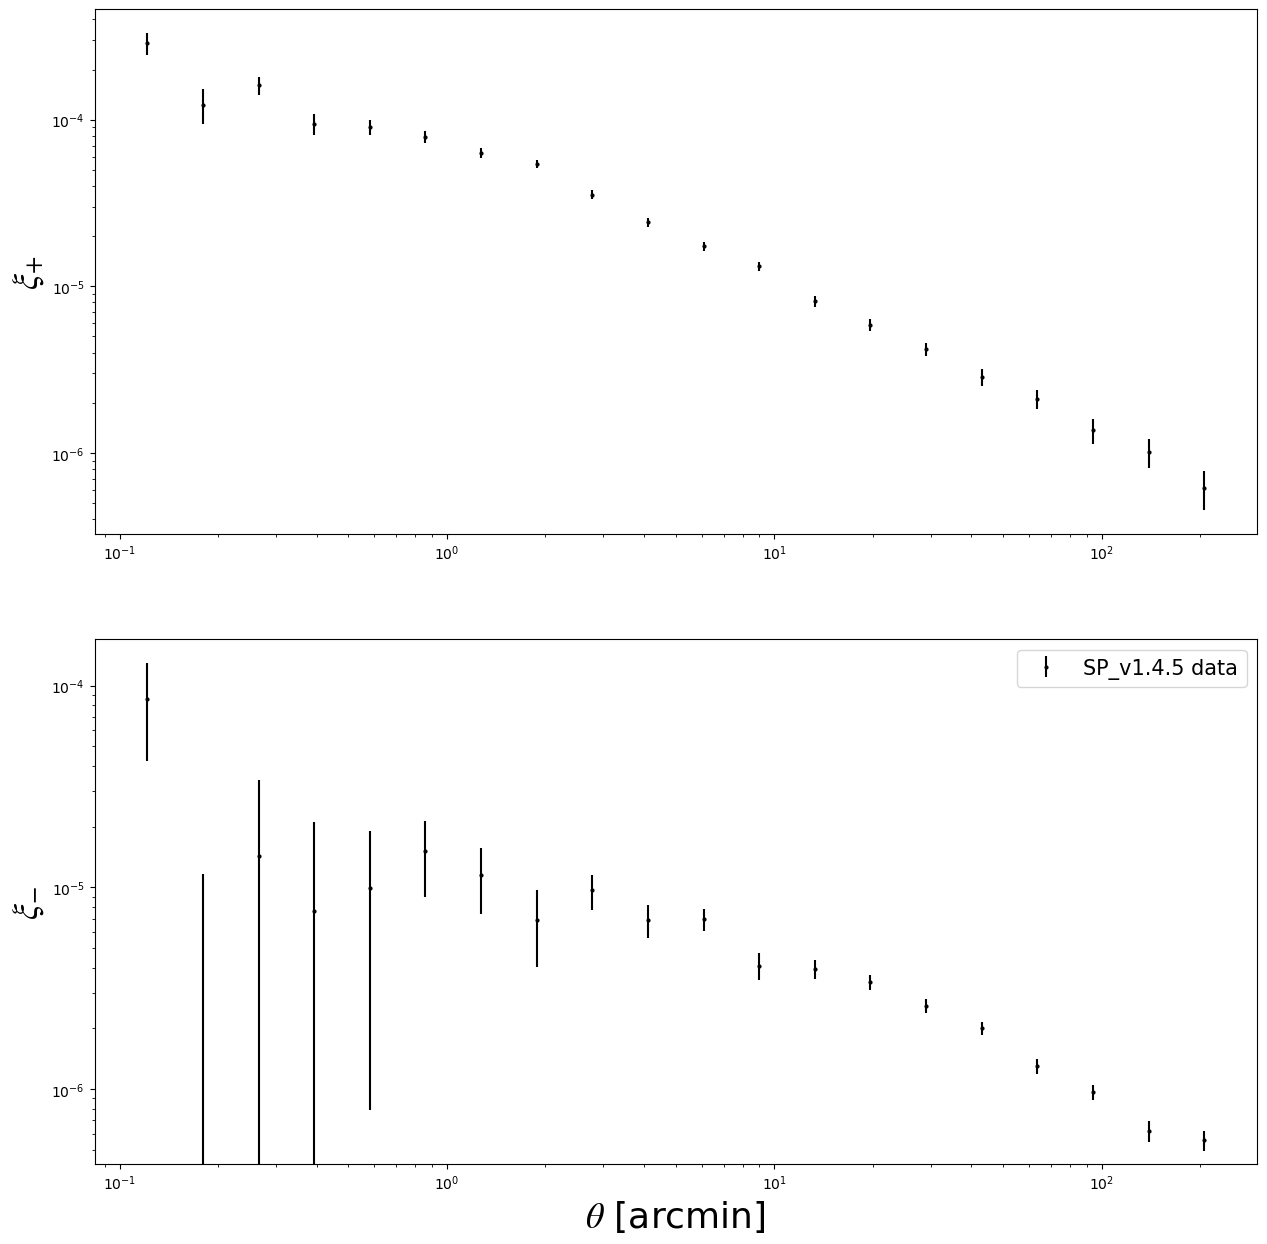

In [124]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

plt.ylabel(r'$\xi_{+}$', fontsize=26)
plt.xscale('log')
plt.yscale('log')

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

plt.xlabel(r'$\theta$ [arcmin]', fontsize=26)
plt.ylabel(r'$\xi_{-}$', fontsize=26)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=15)

plt.show()

In [172]:
def plot_best_fit(root_to_plot, colours, savefile):
    data = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{catalog_version}/cosmosis_SP_v1.4.5.fits')
    xi_plus = data['XI_PLUS'].data
    xi_minus = data['XI_MINUS'].data
    cov_mat = data['COVMAT'].data

    plt.figure(figsize=(15, 15))

    plt.subplot(211)

    plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

    for root, color in zip(root_to_plot, colours):
        add_xi_sys = properties[root]['add_xi_sys']
        lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
        upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
        lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
        upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

        #Read the results
        theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
        theta_arcmin = theta * 180 * 60 / np.pi
        shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
        shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
        xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
        xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
        theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
        theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

        mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
        xi_plus_model = shear_xi_plus[mask]
        if add_xi_sys:
            xi_plus_model += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_plus)
        
        plt.plot(theta_arcmin[mask], xi_plus_model, color=color, label=root, alpha=0.5)
        if add_xi_sys:
            plt.plot(theta_xi_sys_arcmin, xi_sys_plus, color=color, linestyle='-.', alpha=0.5)
        plt.axvline(x=lower_bound_xi_plus, color=color, linestyle='--', alpha=0.3)
        plt.axvline(x=upper_bound_xi_plus, color=color, linestyle='--', alpha=0.3)
        


    plt.ylabel(r'$\xi_{+}$', fontsize=26)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(loc="lower left", fontsize=8)

    plt.subplot(212)

    plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

    for root, color in zip(root_to_plot, colours):
        add_xi_sys = properties[root]['add_xi_sys']
        lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
        upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
        lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
        upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

        #Read the results
        theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
        theta_arcmin = theta * 180 * 60 / np.pi
        shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
        shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
        xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
        xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
        theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
        theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

        mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
        xi_minus_model = shear_xi_minus[mask]
        if add_xi_sys:
            xi_minus_model += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_minus)

        plt.plot(theta_arcmin[mask], xi_minus_model, color=color, label=root, alpha=0.5)
        if add_xi_sys:
            plt.plot(theta_xi_sys_arcmin, np.abs(xi_sys_minus), color=color, linestyle='-.', alpha=0.5)
        plt.axvline(x=lower_bound_xi_minus, color=color, linestyle='--', alpha=0.3)
        plt.axvline(x=upper_bound_xi_minus, color=color, linestyle='--', alpha=0.3)


    plt.xlabel(r'$\theta$ [arcmin]', fontsize=26)
    plt.ylabel(r'$\xi_{-}$', fontsize=26)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(loc="lower left", fontsize=8)

    if savefile is not None:
        plt.savefig(savefile, bbox_inches='tight')

    plt.show()

def plot_best_fit_ratio(root_to_plot, colours, savefile):
    data = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{catalog_version}/cosmosis_SP_v1.4.5.fits')
    xi_plus = data['XI_PLUS'].data
    xi_minus = data['XI_MINUS'].data
    cov_mat = data['COVMAT'].data

    plt.figure(figsize=(15, 15))

    plt.subplot(211)

    root = roots[0]
    add_xi_sys = properties[root]['add_xi_sys']
    lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
    upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
    lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
    upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

    #Read the results
    theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
    theta_arcmin = theta * 180 * 60 / np.pi
    shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
    shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
    xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
    xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
    theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
    theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

    mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
    xi_plus_model_fiducial = shear_xi_plus[mask]
    if add_xi_sys:
        xi_plus_model_fiducial += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_plus)

    plt.errorbar(xi_plus['ANG'], xi_plus['VALUE']/np.interp(xi_plus['ANG'], theta_arcmin[mask], xi_plus_model_fiducial), yerr=np.sqrt(np.diag(cov_mat))[:20]/np.abs(np.interp(xi_plus['ANG'], theta_arcmin[mask], xi_plus_model_fiducial)), fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

    for root, color in zip(root_to_plot, colours):
        add_xi_sys = properties[root]['add_xi_sys']
        lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
        upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
        lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
        upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

        #Read the results
        theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
        theta_arcmin = theta * 180 * 60 / np.pi
        shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
        shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
        xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
        xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
        theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
        theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

        mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
        xi_plus_model = shear_xi_plus[mask]
        if add_xi_sys:
            xi_plus_model += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_plus)
        
        alpha = 1.0 if root==roots[0] else 0.5
        plt.plot(theta_arcmin[mask], xi_plus_model/xi_plus_model_fiducial, color=color, label=root, alpha=alpha)
        plt.axvline(x=lower_bound_xi_plus, color=color, linestyle='--', alpha=0.3)
        plt.axvline(x=upper_bound_xi_plus, color=color, linestyle='--', alpha=0.3)
        


    plt.ylabel(fr'$\xi_{{+}}/\xi_{{+, \text{{{roots[0]}}}}}$', fontsize=26)
    plt.xscale('log')
    #plt.yscale('log')
    plt.legend(loc="lower left", fontsize=8)

    plt.subplot(212)

    root = roots[0]
    add_xi_sys = properties[root]['add_xi_sys']
    lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
    upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
    lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
    upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

    #Read the results
    theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
    theta_arcmin = theta * 180 * 60 / np.pi
    shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
    shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
    xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
    xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
    theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
    theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

    mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
    xi_minus_model_fiducial = shear_xi_minus[mask]
    if add_xi_sys:
        xi_minus_model_fiducial += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_minus)

    plt.errorbar(xi_minus['ANG'], xi_minus['VALUE']/np.interp(xi_minus['ANG'], theta_arcmin[mask], xi_minus_model_fiducial), yerr=np.sqrt(np.diag(cov_mat))[20:40]/np.abs(np.interp(xi_minus['ANG'], theta_arcmin[mask], xi_minus_model_fiducial)), fmt='o', label='SP_v1.4.5 data', color='black', markersize=2)

    for root, color in zip(root_to_plot, colours):
        add_xi_sys = properties[root]['add_xi_sys']
        lower_bound_xi_plus = properties[root]['lower_bound_xi_plus']
        upper_bound_xi_plus = properties[root]['upper_bound_xi_plus']
        lower_bound_xi_minus = properties[root]['lower_bound_xi_minus']
        upper_bound_xi_minus = properties[root]['upper_bound_xi_minus']

        #Read the results
        theta = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/theta.txt'.format(root))
        theta_arcmin = theta * 180 * 60 / np.pi
        shear_xi_plus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_plus/bin_1_1.txt'.format(root))
        shear_xi_minus = np.loadtxt(output_folder + 'best_fit/{}/shear_xi_minus/bin_1_1.txt'.format(root))
        xi_sys_plus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_plus.txt'.format(root))
        xi_sys_minus = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/shear_xi_minus.txt'.format(root))
        theta_xi_sys = np.loadtxt(output_folder + 'best_fit/{}/xi_sys/theta.txt'.format(root))
        theta_xi_sys_arcmin = theta_xi_sys * 180 * 60 / np.pi

        mask = (theta_arcmin > 0.1) & (theta_arcmin < 250)
        xi_minus_model = shear_xi_minus[mask]
        if add_xi_sys:
            xi_minus_model += np.interp(theta_arcmin[mask], theta_xi_sys_arcmin, xi_sys_minus)

        alpha = 1.0 if root==roots[0] else 0.5
        plt.plot(theta_arcmin[mask], xi_minus_model/xi_minus_model_fiducial, color=color, label=root, alpha=alpha)
        plt.axvline(x=lower_bound_xi_minus, color=color, linestyle='--', alpha=0.3)
        plt.axvline(x=upper_bound_xi_minus, color=color, linestyle='--', alpha=0.3)


    plt.xlabel(r'$\theta$ [arcmin]', fontsize=26)
    plt.ylabel(fr'$\xi_{{-}}/\xi_{{-, \text{{{roots[0]}}}}}$', fontsize=26)
    plt.xscale('log')
    plt.ylim(0, 2)
    #plt.yscale('log')
    plt.legend(loc="lower left", fontsize=8)

    if savefile is not None:
        plt.savefig(savefile, bbox_inches='tight')

    plt.show()

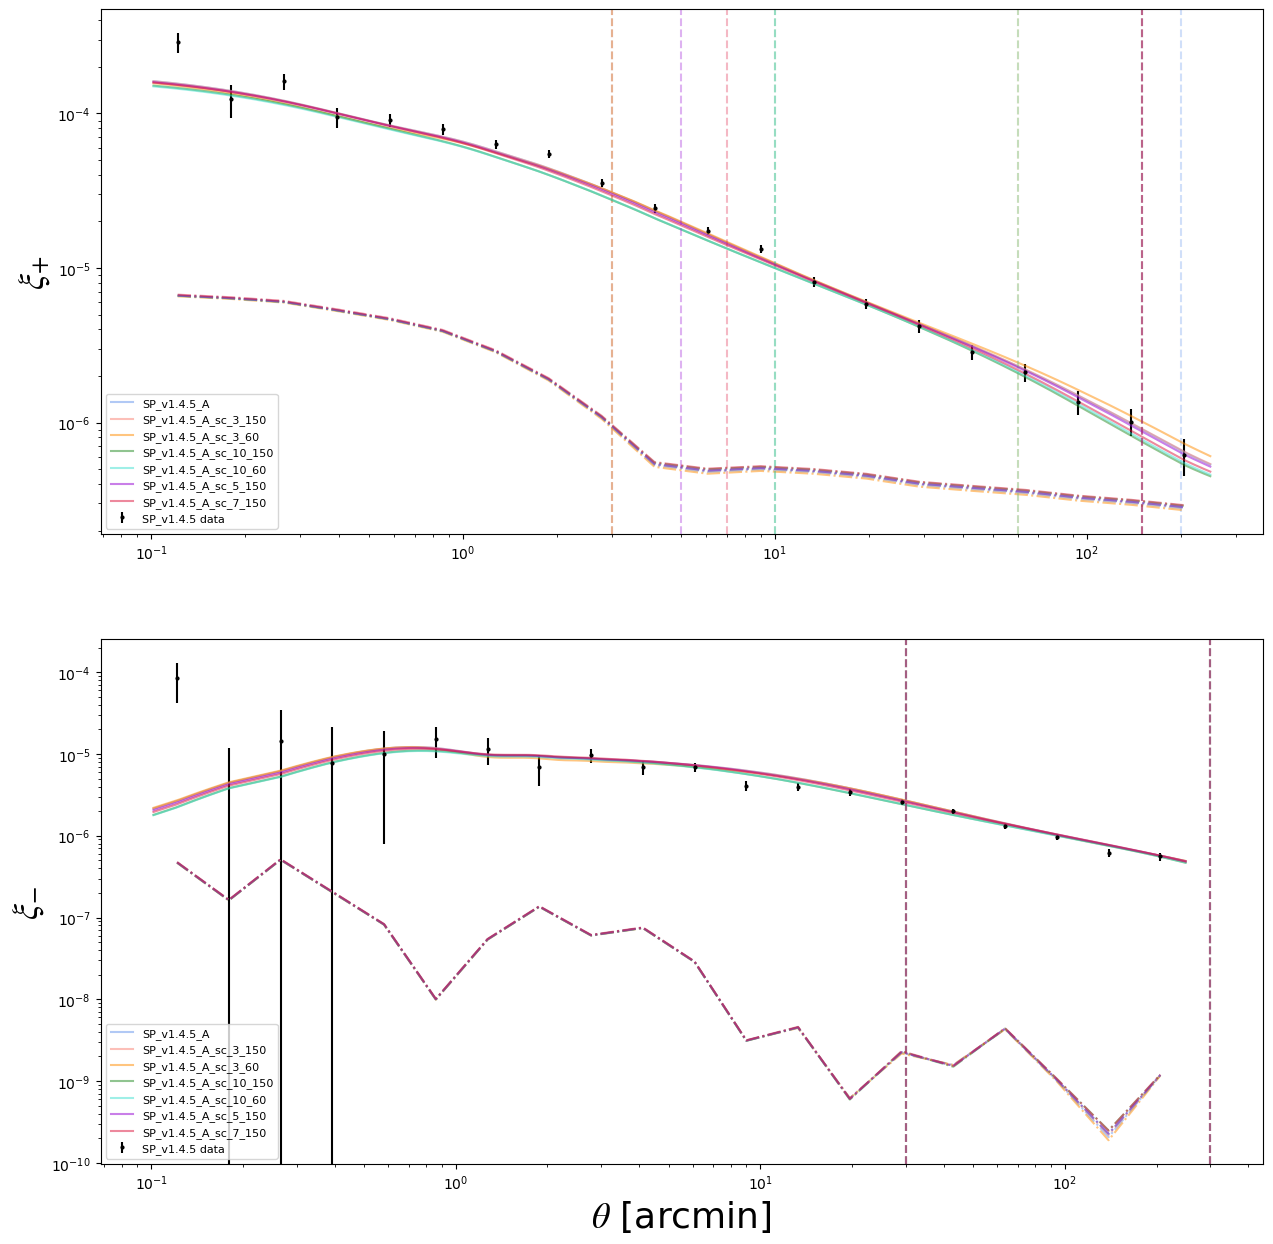

In [155]:
root_to_plot = [
    "SP_v1.4.5_A",
    #"SP_v1.4.5_A_no_IA",
    #"SP_v1.4.5_A_no_dz",
    #"SP_v1.4.5_A_no_m_bias",
    "SP_v1.4.5_A_sc_3_150",
    "SP_v1.4.5_A_sc_3_60",
    "SP_v1.4.5_A_sc_10_150",
    "SP_v1.4.5_A_sc_10_60",
    "SP_v1.4.5_A_sc_5_150",
    "SP_v1.4.5_A_sc_7_150",
    #"SP_v1.4.5_A_no_leakage"
]

colours = [
    'cornflowerblue', 'salmon', 'darkorange', 'forestgreen', 'turquoise', 'darkviolet', 'crimson', 'gold', 'lightcoral', 'mediumseagreen', 'lightsteelblue', 'black', 'silver', 'peru', 'maroon', 'olive'
]

savefile = None

plot_best_fit(root_to_plot, colours, savefile)

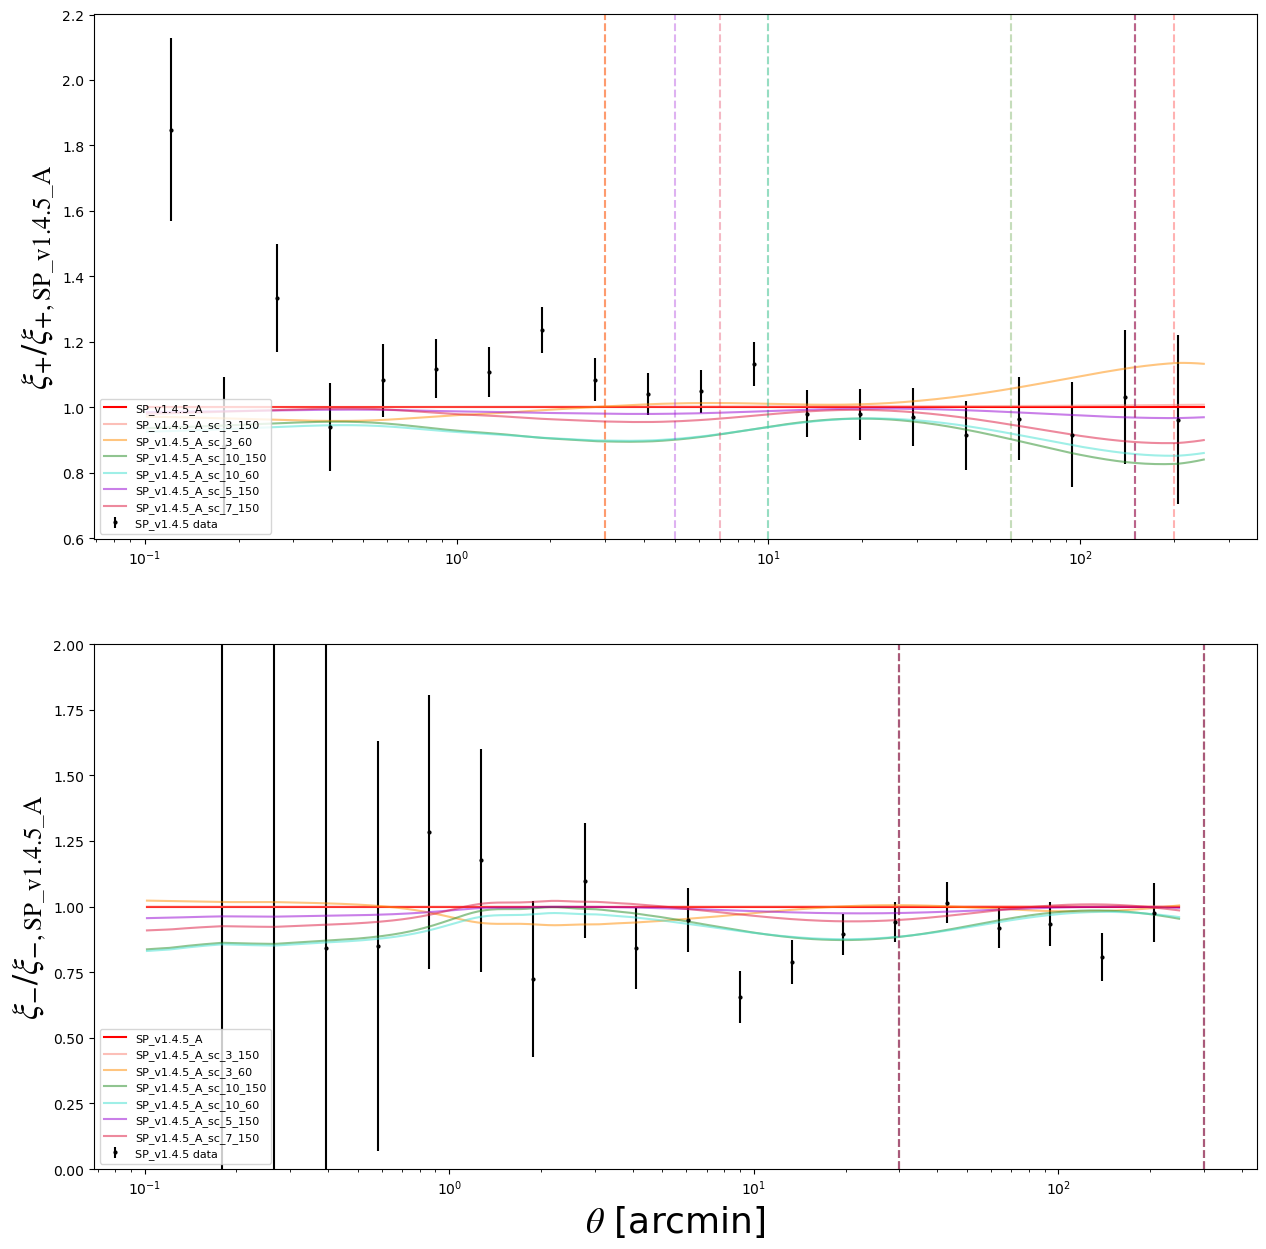

In [176]:
root_to_plot = [
    "SP_v1.4.5_A",
    #"SP_v1.4.5_A_no_IA",
    #"SP_v1.4.5_A_no_dz",
    #"SP_v1.4.5_A_no_m_bias",
    "SP_v1.4.5_A_sc_3_150",
    "SP_v1.4.5_A_sc_3_60",
    "SP_v1.4.5_A_sc_10_150",
    "SP_v1.4.5_A_sc_10_60",
    "SP_v1.4.5_A_sc_5_150",
    "SP_v1.4.5_A_sc_7_150",
    #"SP_v1.4.5_A_no_leakage"
]

colours = [
    'red', 'salmon', 'darkorange', 'forestgreen', 'turquoise', 'darkviolet', 'crimson', 'gold', 'lightcoral', 'mediumseagreen', 'lightsteelblue', 'black', 'silver', 'peru', 'maroon', 'olive'
]

savefile = 'best_fit_scale_cut.pdf'

plot_best_fit_ratio(root_to_plot, colours, savefile)

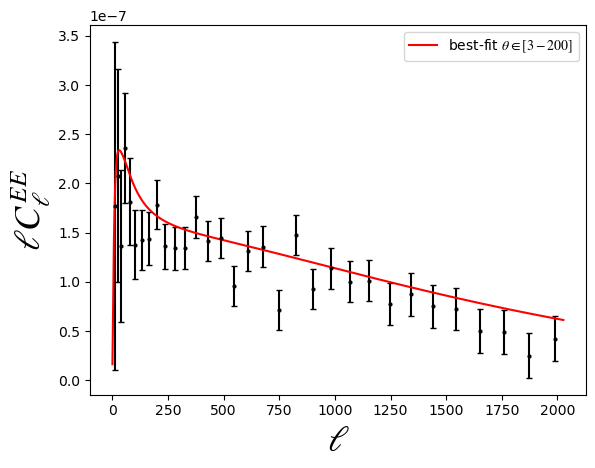

In [10]:
pseudo_cell = fits.open('/home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_SP_v1.4.5.fits')[1].data
cov_pseudo_cell = fits.open('/home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.5.fits')

theory_ell = np.loadtxt('/n09data/guerrini/output_chains/best_fit/SP_v1.4.5_A/shear_cl/ell.txt')
theory_cell = np.loadtxt('/n09data/guerrini/output_chains/best_fit/SP_v1.4.5_A/shear_cl/bin_1_1.txt')

pw = hp.pixwin(1024, lmax=2048)

plt.errorbar(pseudo_cell['ELL'], pseudo_cell['ELL']*pseudo_cell['EE'], yerr=pseudo_cell['ELL']*np.sqrt(np.diag(cov_pseudo_cell['COVAR_EE_EE'].data)), capsize=2, c='k', fmt='o', markersize=2)

mask = (theory_ell > 0.1) & (theory_ell < 2048)
plt.plot(theory_ell[mask], theory_ell[mask]*theory_cell[mask]*np.interp(theory_ell[mask], np.arange(0, 2049), pw)**2, c='r', label='best-fit $\\theta \in [3-200]$')

plt.xlabel(r'$\ell$', fontsize=26)
plt.ylabel(r'$\ell C_\ell^{EE}$', fontsize=26)
plt.legend()
plt.savefig("SP_v1.4.5_A_cell.png")
plt.show()

In [11]:
cov_pseudo_cell.info()

Filename: /home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.5.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  COVAR_EE_EE    1 PrimaryHDU       7   (32, 32)   float64   
  1  COVAR_EE_EB    1 ImageHDU         8   (32, 32)   float64   
  2  COVAR_EE_BE    1 ImageHDU         8   (32, 32)   float64   
  3  COVAR_EE_BB    1 ImageHDU         8   (32, 32)   float64   
  4  COVAR_EB_EE    1 ImageHDU         8   (32, 32)   float64   
  5  COVAR_EB_EB    1 ImageHDU         8   (32, 32)   float64   
  6  COVAR_EB_BE    1 ImageHDU         8   (32, 32)   float64   
  7  COVAR_EB_BB    1 ImageHDU         8   (32, 32)   float64   
  8  COVAR_BE_EE    1 ImageHDU         8   (32, 32)   float64   
  9  COVAR_BE_EB    1 ImageHDU         8   (32, 32)   float64   
 10  COVAR_BE_BE    1 ImageHDU         8   (32, 32)   float64   
 11  COVAR_BE_BB    1 ImageHDU         8   (32, 32)   float64   
 12  COVAR_BB_EE    1 ImageHDU         8   (32, 32)   float64  